In [ ]:
# Imports
import numpy as np
from scipy.linalg import eig
import matplotlib.pyplot as plt


In [2]:
# Array of r values
dr = 0.5
N = 100
r_values = np.arange(N) * dr + dr

# Defining constants
U = 1
H = 1
k = np.ones(N)
v_parallel = 1

# Bias voltage (equilibrium potential)
phi_0 = 1.0 - r_values**2

# Equilibrium pressure
p_0 = np.exp(-r_values**2)

# Which mode
m = 1

# Matrix Helper Functions

In [3]:
def create_first_derivative_matrix(N, dx):
    matrix = np.zeros((N,N))

    for i in range(1, N-1, 1):
        matrix[i][i+1] = 1 
        matrix[i][i-1] = -1

    matrix[0][0] = -3 
    matrix[0][1] = 4
    matrix[0][2] = -1

    matrix[N-1][N-3] = 1 
    matrix[N-1][N-2] = -4
    matrix[N-1][N-1] = 3

    return matrix / (2 * dx)

def create_second_derivative_matrix(N, dx):
    matrix = np.zeros((N,N))

    for i in range(1, N-1, 1):
        matrix[i][i+1] = 1 
        matrix[i][i] = -2
        matrix[i][i-1] = 1

    matrix[0][0] = 2
    matrix[0][1] = -5
    matrix[0][2] = 4
    matrix[0][3] = -1

    matrix[N-1][N-4] = -1
    matrix[N-1][N-3] = 4
    matrix[N-1][N-2] = -5
    matrix[N-1][N-1] = 2

    return matrix / (dx ** 2)

def create_third_derivative_matrix(N, dx):
    matrix = np.zeros((N,N))

    for i in range(2, N-2, 1):
        matrix[i][i-2] = -1
        matrix[i][i-1] = 2
        matrix[i][i+1] = -2
        matrix[i][i+2] = 1

    matrix[0][0] = -5
    matrix[0][1] = 18
    matrix[0][2] = -24
    matrix[0][3] = 14
    matrix[0][4] = -3

    matrix[N-1][N-1] = 5
    matrix[N-1][N-2] = -18
    matrix[N-1][N-3] = 24
    matrix[N-1][N-4] = -14
    matrix[N-1][N-5] = 3

    matrix[1][0] = -3
    matrix[1][1] = 10
    matrix[1][2] = -12
    matrix[1][3] = 6
    matrix[1][4] = -1

    matrix[N-2][N-1] = 3
    matrix[N-2][N-2] = -10
    matrix[N-2][N-3] = 12
    matrix[N-2][N-4] = -6
    matrix[N-2][N-5] = 1

    return (matrix / (2 * (dx ** 3)))

def create_m_laplacian(N, dx, m, r_values):
    D1 = create_first_derivative_matrix(N, dx)
    D2 = create_second_derivative_matrix(N, dx)

    return (
        D2
        + np.diag(1 / r_values) @ D1
        - np.diag(m**2 / (r_values**2))
    )

# Dirichlet boundary conditions at edge
# NOTE: may want to impose boundary conditions for phi[0] later on....
# This is for eigenvalue problem gamma Ax = Bx, phi(r = R) = 0
def enforce_bc(A, B):
    A[N-1][:] = 0
    B[N-1][:] = 0
    B[N-1][N-1] = 1

    return A, B

## Linear Stability Operator

The eigenvalue problem to be solved is:

$$
\gamma
\begin{pmatrix} \Delta_m & 0 \\ 0 & 1 \end{pmatrix}
\begin{pmatrix} \hat\varphi \\ \hat\rho \end{pmatrix}
=
\begin{pmatrix} \mathcal{L}_{11} & \mathcal{L}_{12} \\ \mathcal{L}_{21} & \mathcal{L}_{22} \end{pmatrix}
\begin{pmatrix} \hat\varphi \\ \hat\rho \end{pmatrix}.
$$

### Linear operators (expanded form)

$$
\mathcal{L}_{11}
  = -im\Omega_0 \Delta_m
    + \frac{im}{r}(\Delta\varphi_0)'
    - \frac{imU}{r}\left(P_0''\frac{\partial}{\partial r} + P_0'\,\frac{\partial^2}{\partial r^2}\right)
    + \frac{im^3 U}{r^3}\,P_0'
    + H
    - \nu_\parallel \Delta_m,
$$

$$
\mathcal{L}_{12}
  = \frac{imU}{r}\left(\varphi_0''' + \varphi_0''\,\frac{\partial}{\partial r}\right) - 2im\mathcal{K},
$$

$$
\mathcal{L}_{21} = \frac{im}{r}P_0'(r),
$$

$$
\mathcal{L}_{22} = -\nu_\parallel^P - im\Omega_0(r).
$$

where
$$\Omega_0(r) \equiv \frac{1}{r}\frac{\partial \varphi_0}{\partial r}, \quad \text{where } \varphi_0 \text{ is the equilibrium potential.}$$

and 

$$
(\Delta\varphi_0)' = \varphi_0''' + \frac{\varphi_0''}{r} - \frac{\varphi_0'}{r^2}.
$$

In [4]:
# Initalizing matrices
D1 = create_first_derivative_matrix(N, dr)
D2 = create_second_derivative_matrix(N, dr)
D3 = create_third_derivative_matrix(N, dr)
Dm = create_m_laplacian(N, dr, m, r_values)

diag_r = np.diag(r_values)
diag_div_r = np.diag(1 / r_values)

omega_0_diag = diag_div_r @ np.diag(D1 @ phi_0)
D_phi_prime_diag = np.diag((D3 + diag_div_r @ D2 - np.diag(1 / (r_values ** 2)) @ D1) @ phi_0)

# Defining opereators
L11 = (-1j * m * omega_0_diag @ Dm 
       + 1j * m * diag_div_r @ D_phi_prime_diag 
       - 1j * m * U * diag_div_r @ (np.diag(D2 @ p_0) @ D1 + np.diag(D1 @ p_0) @ D2) 
       + 1j * (m ** 3) * U * np.diag(1 / (r_values ** 3)) @ np.diag(D1 @ p_0) 
       + np.diag(np.ones(N) * H) 
       - v_parallel * Dm)

L12 = 1j * m * U * diag_div_r @ (np.diag(D3 @ phi_0) + np.diag(D2 @ phi_0) @ D1) - 2j * m * np.diag(k)
L21 = 1j * m * np.diag(1 / r_values) @ np.diag(D1 @ p_0)
L22 = -np.diag(np.ones(N) * v_parallel) - (1j * m * omega_0_diag)

In [5]:
# Reduce eigenvalue problem to gamma * Ax = Bx

A = np.block([
    [Dm, np.zeros((N,N))],
    [np.zeros((N,N)), np.eye(N)]
])

B = np.block([
    [L11, L12],
    [L21, L22]
])

A, B = enforce_bc(A, B)

In [ ]:
eigenvalues, eigenvectors = eig(B, A)

# Each column of eigenvectors is an eigenvector
x0 = eigenvectors[:, 0]  # eigenvector for eigenvalues[0]

In [9]:
eigenvalues

array([-171.28887625+2.00328541j,  -51.80899602+2.00587381j,
        -25.17110892+2.00837691j,  -15.09975487+2.01073373j,
        -10.23235168+2.01285665j,   -7.51353938+2.01463811j,
         -5.84162026+2.01597546j,   -4.74040871+2.0168098j ,
         -3.97677624+2.01715629j,   -1.23492182+4.10572673j,
         -3.42564005+2.01710156j,   -3.01497411+2.01676969j,
         -2.70090542+2.01628166j,   -2.45547081+2.01572906j,
         -2.26018609+2.01516083j,   -2.10247646+2.0145631j ,
         -1.97358568+2.01379633j,   -0.50215439+1.53242421j,
         -1.86719797+2.01246137j,   -1.77821295+2.00989639j,
         -1.70183518+2.00598589j,   -1.59409334+1.86814681j,
         -1.63435899+2.00220684j,   -1.5747822 +2.00040652j,
         -1.03507823+1.64077801j,   -1.5234253 +2.00026534j,
         -1.21183156+2.31371905j,   -1.47930775+2.0005502j ,
         -1.44101449+2.00079083j,   -1.40745543+2.00092077j,
         -1.37783077+2.00096173j,   -1.35152835+2.00094323j,
         -1.32806207+2.0

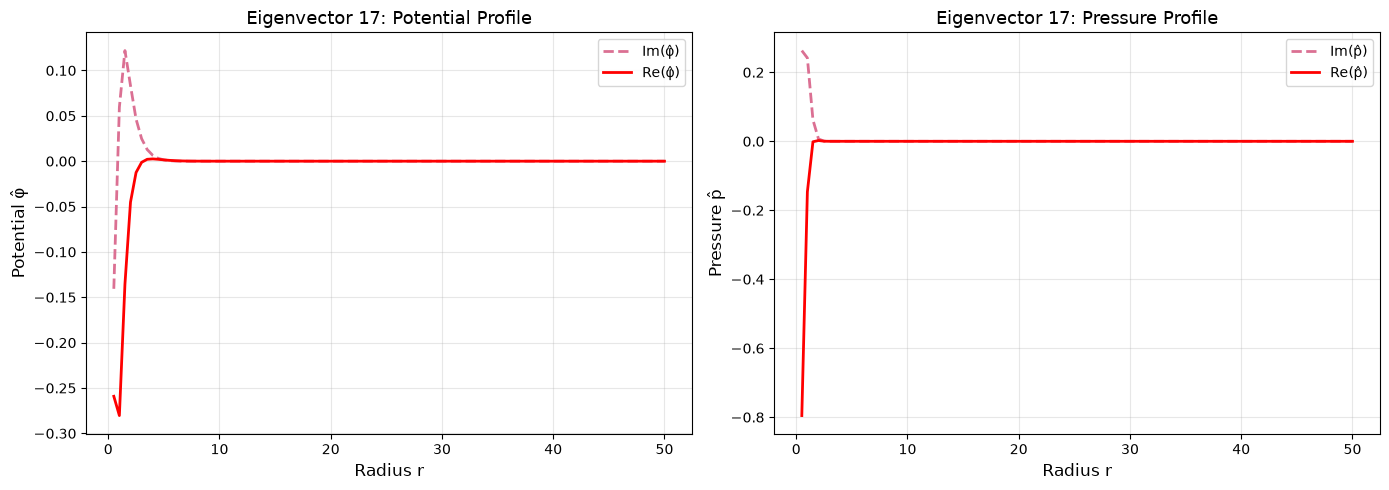

In [10]:
# Extract potential and pressure from eigenvector
N = 100

# Eigenvalue for null space vectors are inf, so we only look at the finite eigenvalues
finite_mask = np.isfinite(eigenvalues)
finite_evals = eigenvalues[finite_mask]
finite_indices = np.where(finite_mask)[0]
eigenvector_index = finite_indices[np.argmax(np.real(finite_evals))]

eigenvector = eigenvectors[:, eigenvector_index]
potential = eigenvector[:N]
pressure = eigenvector[N:2*N]

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot potential
ax1.plot(r_values, np.imag(potential), '--', linewidth=2, label='Im(φ̂)', color='palevioletred')
ax1.plot(r_values, np.real(potential), linewidth=2, label='Re(φ̂)', color='red')
ax1.set_xlabel('Radius r', fontsize=12)
ax1.set_ylabel('Potential φ̂', fontsize=12)
ax1.set_title(f'Eigenvector {eigenvector_index}: Potential Profile', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot pressure
ax2.plot(r_values, np.imag(pressure), '--', linewidth=2, label='Im(p̂)', color='palevioletred')
ax2.plot(r_values, np.real(pressure), linewidth=2, label='Re(p̂)', color='red')
ax2.set_xlabel('Radius r', fontsize=12)
ax2.set_ylabel('Pressure p̂', fontsize=12)
ax2.set_title(f'Eigenvector {eigenvector_index}: Pressure Profile', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()